# Laboratorium 6: Klasyfikacja danych niezrównoważonych

**Aplikacja randkowa Habibi** — przewidywanie matchów na danych *Speed Dating*.


## Import bibliotek


In [1]:
import ast
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score, brier_score_loss
)

from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style("whitegrid")
%matplotlib inline


## Zadanie 1.1: Pobranie danych i EDA


### 1.1a: Wstępny rzut oka na surowe dane

Ładujemy dane i sprawdzamy co w nich jest, zanim cokolwiek zmienimy.


In [2]:
# Wczytanie surowych danych
df = pd.read_csv("data/speeddating.csv")
print(f"Wierszy: {df.shape[0]}, kolumn: {df.shape[1]}")
print(f"\nTypy kolumn:")
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)
print(f"\nLiczba braków: {df.isnull().sum().sum()}")
print(f"Liczba duplikatów: {df.duplicated().sum()}")
df.head()


Wierszy: 8378, kolumn: 123

Typy kolumn:
str        64
float64    59
Name: count, dtype: int64

Liczba braków: 18173
Liczba duplikatów: 0


,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,b'',1.0,b'female',21.0,27.0,6.0,b'[4-6]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'0',b'0'
1,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,5.0,b'[6-8]',b'[5-6]',1.0,b'1',b'0',b'0'
2,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',...,b'[0-3]',b'[3-5]',7.0,NaN,b'[6-8]',b'[0-4]',1.0,b'1',b'1',b'1'
3,b'',1.0,b'female',21.0,23.0,2.0,b'[2-3]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'1',b'1'
4,b'',1.0,b'female',21.0,24.0,3.0,b'[2-3]',b'Asian/Pacific Islander/Asian-American',b'Latino/Hispanic American',b'0',...,b'[0-3]',b'[3-5]',6.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'1',b'1'


Sprawdzamy jak wyglądają wartości w kolumnach. Wiele z nich ma zapis `b'...'` — to stringi repr-reprezentujące bajty. Trzeba będzie to wyczyścić, ale najpierw zobaczmy co dokładnie jest w środku.


In [3]:
sample_cols = ['gender', 'race', 'match', 'samerace', 'field', 'sports']
for c in sample_cols:
    vals = df[c].dropna().unique()[:5]
    print(f"\n{c}: dtype={df[c].dtype}, unique={df[c].nunique()}")
    print(f"  przykłady: {vals}")
d_cols = [c for c in df.columns if c.startswith('d_')]
print(f"\nKolumny z prefiksem d_: {len(d_cols)} (róznice)")
o_cols = [c for c in df.columns if c.endswith('_o')]
print(f"Kolumny z sufiksem _o: {len(o_cols)} (oceny partnera)")
partner_cols = [c for c in df.columns if c.endswith('_partner')]
print(f"Kolumny z sufiksem _partner: {len(partner_cols)} (samooceny partnera)")



gender: dtype=str, unique=2
  przykłady: <StringArray>
['b'female'', 'b'male'']
Length: 2, dtype: str

race: dtype=str, unique=6
  przykłady: <StringArray>
['b'Asian/Pacific Islander/Asian-American'',
           'b'European/Caucasian-American'',
                                 'b'Other'',
              'b'Latino/Hispanic American'',
                'b'Black/African American'']
Length: 5, dtype: str

match: dtype=str, unique=2
  przykłady: <StringArray>
['b'0'', 'b'1'']
Length: 2, dtype: str

samerace: dtype=str, unique=2
  przykłady: <StringArray>
['b'0'', 'b'1'']
Length: 2, dtype: str

field: dtype=str, unique=260
  przykłady: <StringArray>
[                             'b'Law'',                              'b'law'',
                        'b'Economics'', 'b'Masters in Public Administration'',
 'b'Masters of Social Work&Education'']
Length: 5, dtype: str

sports: dtype=float64, unique=10
  przykłady: [ 9.  3.  1.  7. 10.]

Kolumny z prefiksem d_: 56 (róznice)
Kolumny z sufiksem _o

Konwertujemy kolumny z formatu `b'...'` na normalne wartości. Używamy `ast.literal_eval` — bezpieczne parsowanie stringów reprezentujących literały Pythona.


In [4]:
def clean_bytes(x):
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, bytes):
                return val.decode('utf-8')
            return val
        except (ValueError, SyntaxError):
            return x
    return x

str_cols = []
for col in df.columns:
    if df[col].dropna().shape[0] > 0:
        sample = df[col].dropna().iloc[0]
        if isinstance(sample, str) and sample.startswith('b'):
            df[col] = df[col].apply(clean_bytes)
            str_cols.append(col)

print(f"Przekonwertowano {len(str_cols)} kolumn z formatu b'...'")
print(f"Np.: {str_cols[:10]}...")


Przekonwertowano 64 kolumn z formatu b'...'
Np.: ['has_null', 'gender', 'd_d_age', 'race', 'race_o', 'samerace', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'd_pref_o_attractive']...


### 1.1b: Analiza klasy docelowej (match)

Match to kolumna docelowa. Sprawdźmy jej rozkład i kontekst.


Rozkład klasy docelowej:
match
0    6998
1    1380
Name: count, dtype: int64

Proporcja match = 1: 0.165
Współczynnik niezrównoważenia: 5.1:1


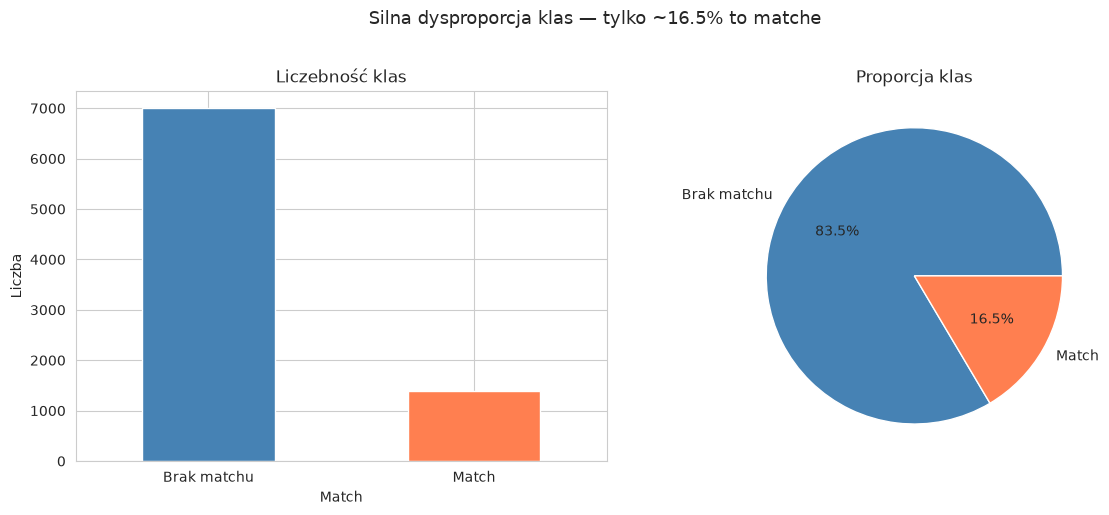

In [5]:
df['match'] = pd.to_numeric(df['match']).astype(int)

print("Rozkład klasy docelowej:")
print(df['match'].value_counts())
print(f"\nProporcja match = 1: {df['match'].mean():.3f}")
print(f"Współczynnik niezrównoważenia: "
      f"{df['match'].value_counts().iloc[0] / df['match'].value_counts().iloc[1]:.1f}:1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df['match'].value_counts().plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_title("Liczebność klas")
ax1.set_xlabel("Match"); ax1.set_ylabel("Liczba")
ax1.set_xticklabels(["Brak matchu", "Match"], rotation=0)

df['match'].value_counts(normalize=True).plot(
    kind='pie', ax=ax2, autopct='%1.1f%%',
    colors=['steelblue', 'coral'], labels=["Brak matchu", "Match"])
ax2.set_ylabel(""); ax2.set_title("Proporcja klas")

plt.suptitle("Silna dysproporcja klas — tylko ~16.5% to matche", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### 1.1c: Demografia — wiek, płeć, rasa

Sprawdzamy cechy demograficzne uczestników i ich związek z szansą na match.


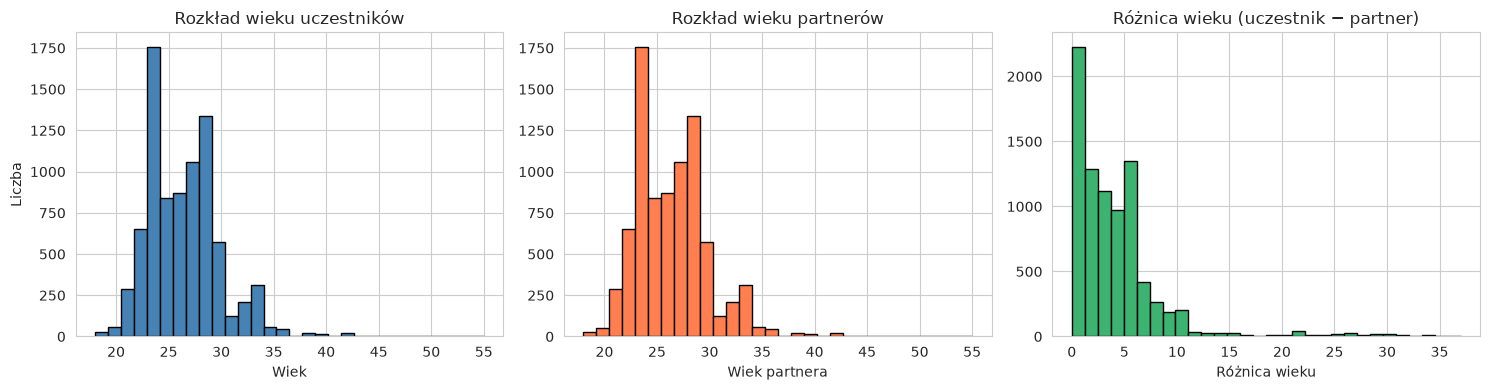

Wiek: min=18, max=55, średnia=26.4, braki=95


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("Rozkład wieku uczestników")
axes[0].set_xlabel("Wiek"); axes[0].set_ylabel("Liczba")

axes[1].hist(df['age_o'].dropna(), bins=30, color='coral', edgecolor='black')
axes[1].set_title("Rozkład wieku partnerów")
axes[1].set_xlabel("Wiek partnera")

axes[2].hist(df['d_age'].dropna(), bins=30, color='mediumseagreen', edgecolor='black')
axes[2].set_title("Różnica wieku (uczestnik − partner)")
axes[2].set_xlabel("Różnica wieku")

plt.tight_layout(); plt.show()
print(f"Wiek: min={df['age'].min():.0f}, max={df['age'].max():.0f}, "
      f"średnia={df['age'].mean():.1f}, braki={df['age'].isna().sum()}")


Match rate wg płci:
       label  match_rate  count
0    Kobiety    0.164914   4184
1  Mężczyźni    0.164521   4194

Match rate wg rasy:


,mean,count
race,,
?,0.222,63
Black/African American,0.202,420
Other,0.197,522
Latino/Hispanic American,0.185,664
European/Caucasian-American,0.167,4727
Asian/Pacific Islander/Asian-American,0.135,1982


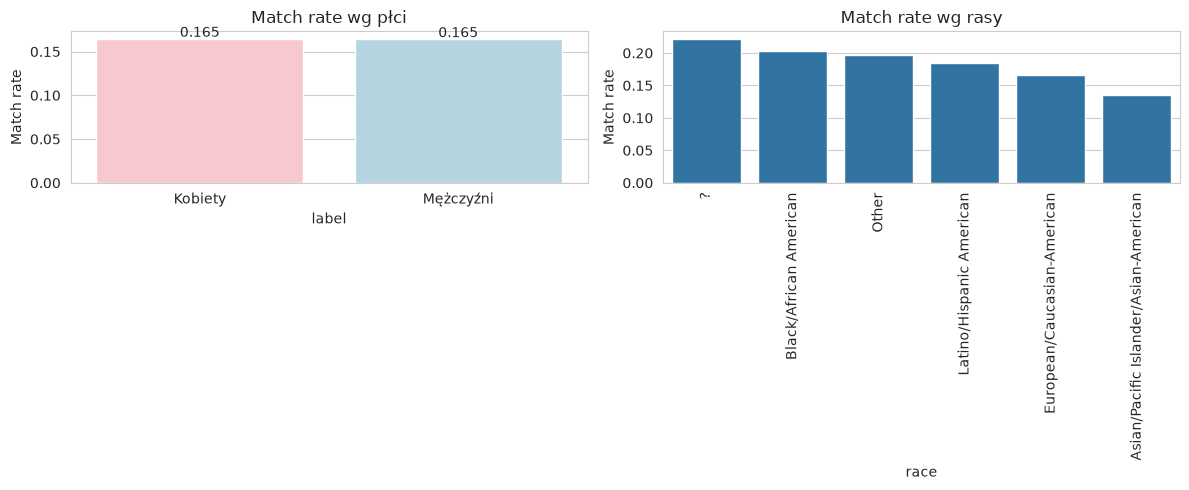

In [7]:
gender_match = df.groupby('gender')['match'].agg(['mean', 'count']).reset_index()
gender_match.columns = ['gender', 'match_rate', 'count']
gender_match['label'] = gender_match['gender'].map({'female': 'Kobiety', 'male': 'Mężczyźni'})
print("Match rate wg płci:")
print(gender_match[['label', 'match_rate', 'count']])

race_match = df.groupby('race')['match'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("\nMatch rate wg rasy:")
display(race_match.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=gender_match, x='label', y='match_rate', palette=['pink', 'lightblue'], ax=ax1)
ax1.set_title("Match rate wg płci"); ax1.set_ylabel("Match rate")
for i, row in gender_match.iterrows():
    ax1.text(i, row['match_rate'] + 0.002, f"{row['match_rate']:.3f}", ha='center')

sns.barplot(data=race_match.reset_index(), x='race', y='mean', ax=ax2)
ax2.set_title("Match rate wg rasy"); ax2.set_ylabel("Match rate")
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout(); plt.show()


### 1.1d: Samooceny i preferencje

Uczestnicy oceniali siebie w skali 1-10 w kategoriach: atrakcyjność, szczerość, inteligencja, poczucie humoru, ambicja. Określali też jak ważna jest każda cecha u partnera (skala 1-100) oraz zgadywali czego szuka druga osoba (`pref_o_*`).


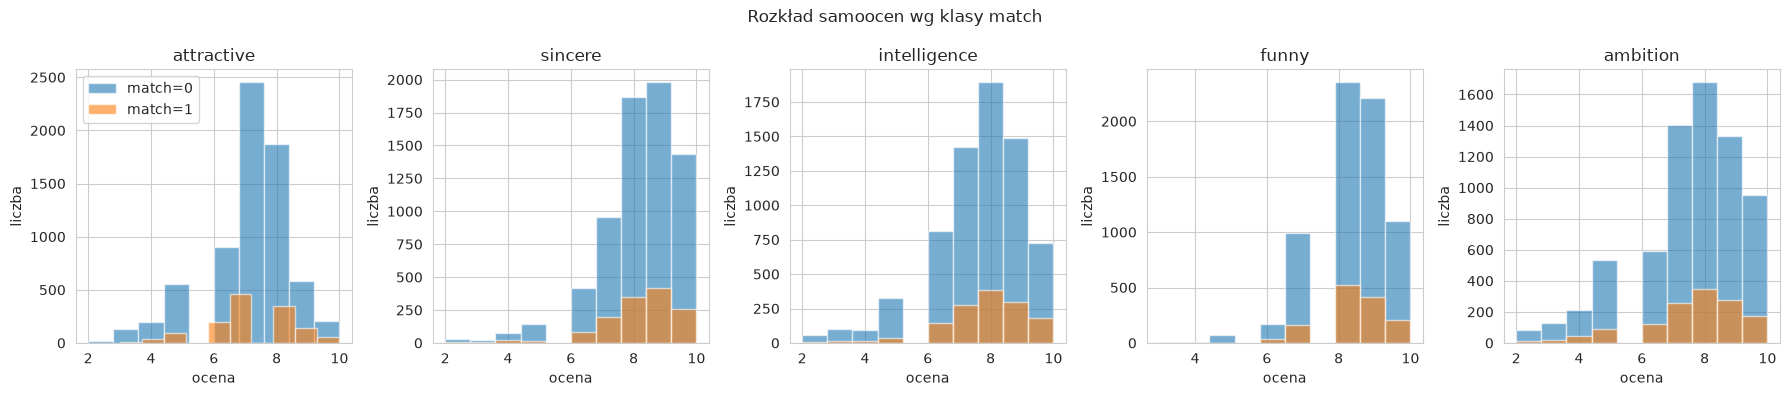

Match rate wg samooceny atrakcyjności:


,mean,count
attractive,,
2.0,0.000,20
3.0,0.069,145
4.0,0.160,238
5.0,0.143,642
6.0,0.183,1100
7.0,0.159,2914
8.0,0.156,2217
9.0,0.196,729
10.0,0.220,268


In [8]:
self_cols = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(self_cols):
    for match_val in [0, 1]:
        subset = df[df['match'] == match_val][col].dropna()
        axes[i].hist(subset, bins=10, alpha=0.6, label=f'match={match_val}')
    axes[i].set_title(col)
    axes[i].set_xlabel("ocena"); axes[i].set_ylabel("liczba")
axes[0].legend()
plt.suptitle("Rozkład samoocen wg klasy match")
plt.tight_layout(); plt.show()

print("Match rate wg samooceny atrakcyjności:")
match_by_attr = df.groupby('attractive')['match'].agg(['mean', 'count'])
display(match_by_attr.round(3))


Średnia ważność cech (1-100):
  Atrakcyjność: 22.5
  Inteligencja: 20.3
  Humor: 17.5
  Szczerość: 17.4
  Zainteresowania: 11.8
  Ambicja: 10.7


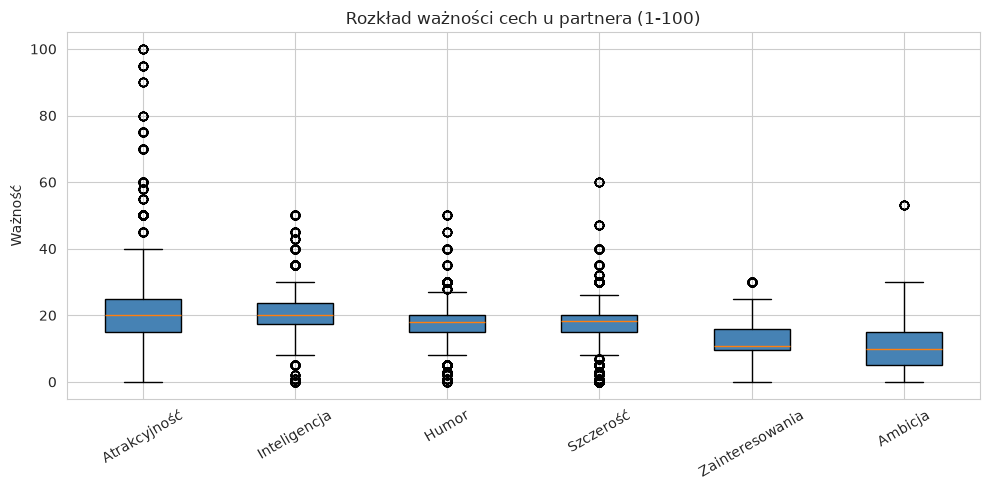

In [9]:
imp_cols = ['attractive_important', 'sincere_important', 'intellicence_important',
            'funny_important', 'ambtition_important', 'shared_interests_important']
imp_labels = ['Atrakcyjność', 'Szczerość', 'Inteligencja', 'Humor', 'Ambicja', 'Zainteresowania']

imp_means = df[imp_cols].mean().sort_values(ascending=False)
sorted_labels = [imp_labels[imp_cols.index(c)] for c in imp_means.index]

print("Średnia ważność cech (1-100):")
for col, label in zip(imp_means.index, sorted_labels):
    print(f"  {label}: {df[col].mean():.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([df[c].dropna() for c in imp_means.index],
                patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
ax.set_xticklabels(sorted_labels, rotation=30)
ax.set_title("Rozkład ważności cech u partnera (1-100)")
ax.set_ylabel("Ważność")
plt.tight_layout(); plt.show()


### 1.1e: Hobby i zainteresowania

17 kategorii hobby ocenianych w skali 1-10. Sprawdzamy które hobby najbardziej różnicują match od braku matchu.


Różnica średnich hobby (Match − Brak matchu):


,Brak matchu,Match,diff
clubbing,5.68,6.06,0.37
yoga,4.30,4.56,0.27
art,6.68,6.88,0.19
hiking,5.71,5.88,0.17
dining,7.76,7.92,0.16
concerts,6.80,6.96,0.16
sports,6.40,6.55,0.15
music,7.83,7.94,0.11
reading,7.66,7.77,0.11
gaming,3.87,3.96,0.10


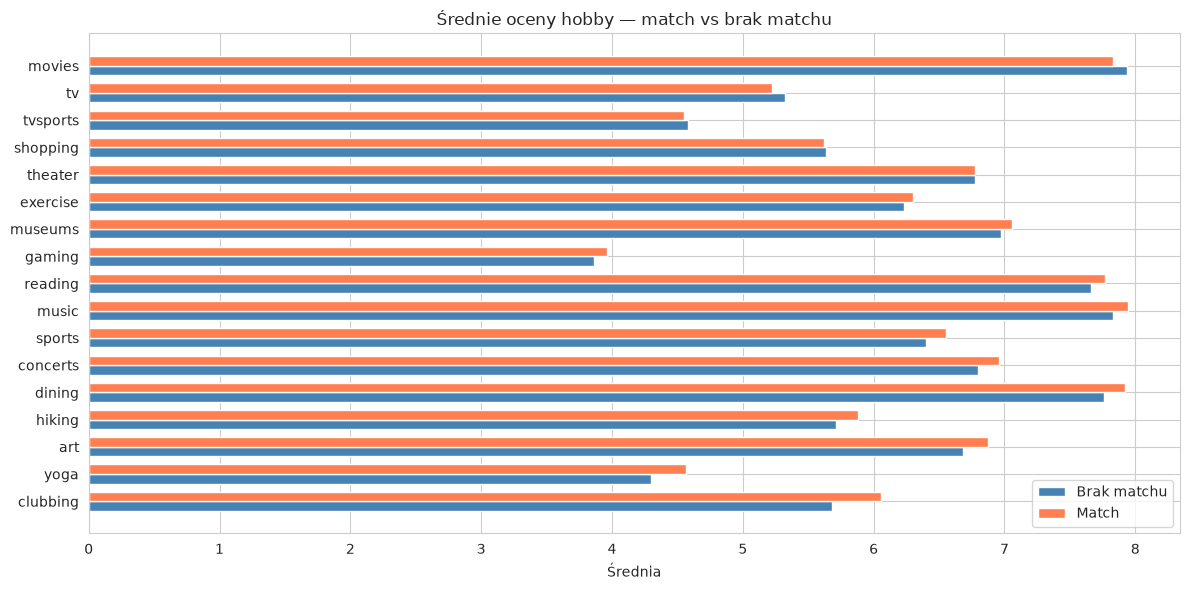

In [10]:
hobby_cols = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art',
              'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater',
              'movies', 'concerts', 'music', 'shopping', 'yoga']
hobby_labels = [c.capitalize() for c in hobby_cols]

hobby_match = df.groupby('match')[hobby_cols].mean().T
hobby_match.columns = ['Brak matchu', 'Match']
hobby_match['diff'] = hobby_match['Match'] - hobby_match['Brak matchu']
hobby_match = hobby_match.sort_values('diff', ascending=False)

print("Różnica średnich hobby (Match − Brak matchu):")
display(hobby_match.round(2).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(hobby_match))
width = 0.35
ax.barh(x, hobby_match['Brak matchu'], width, label='Brak matchu', color='steelblue')
ax.barh([i + width for i in x], hobby_match['Match'], width, label='Match', color='coral')
ax.set_yticks([i + width/2 for i in x])
ax.set_yticklabels(hobby_match.index)
ax.set_xlabel("Średnia"); ax.set_title("Średnie oceny hobby — match vs brak matchu")
ax.legend()
plt.tight_layout(); plt.show()


### 1.1f: Brakujące dane

Sprawdzamy gdzie są braki i decydujemy co z nimi zrobić.


Top 20 kolumn z największą liczbą braków:


,braki,%
expected_num_interested_in_me,6578,78.5
expected_num_matches,1173,14.0
shared_interests_o,1076,12.8
shared_interests_partner,1067,12.7
ambitous_o,722,8.6
ambition_partner,712,8.5
met,375,4.5
funny_o,360,4.3
funny_partner,350,4.2
guess_prob_liked,309,3.7



Łącznie brakujących wartości: 18173
Kolumny z >50% braków: 1


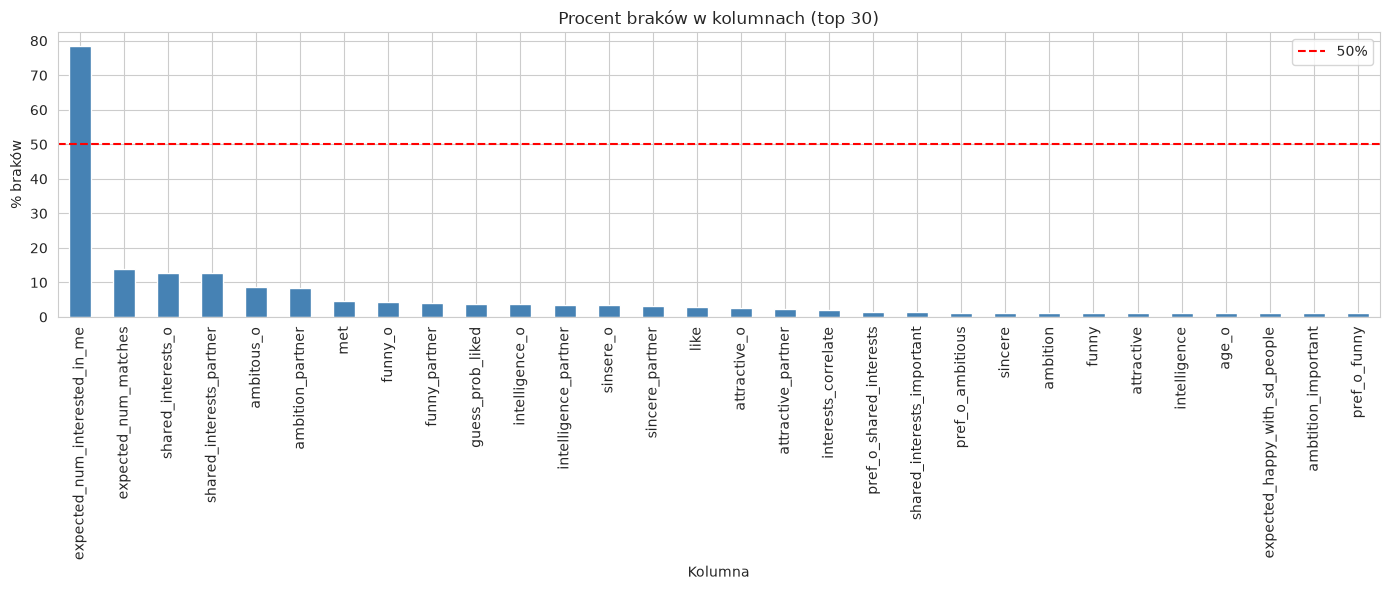

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 20 kolumn z największą liczbą braków:")
display(pd.DataFrame({'braki': missing.head(20), '%': missing_pct.head(20).round(1)}))
print(f"\nŁącznie brakujących wartości: {df.isnull().sum().sum()}")
print(f"Kolumny z >50% braków: {(missing_pct > 50).sum()}")

fig, ax = plt.subplots(figsize=(14, 6))
missing_pct[missing_pct > 0].sort_values(ascending=False).head(30).plot(
    kind='bar', ax=ax, color='steelblue')
ax.set_title("Procent braków w kolumnach (top 30)")
ax.set_ylabel("% braków"); ax.set_xlabel("Kolumna")
ax.axhline(y=50, color='red', linestyle='--', label='50%')
ax.legend()
plt.tight_layout(); plt.show()


### 1.1g: Korelacje

Macierz korelacji dla kluczowych cech profilowych.


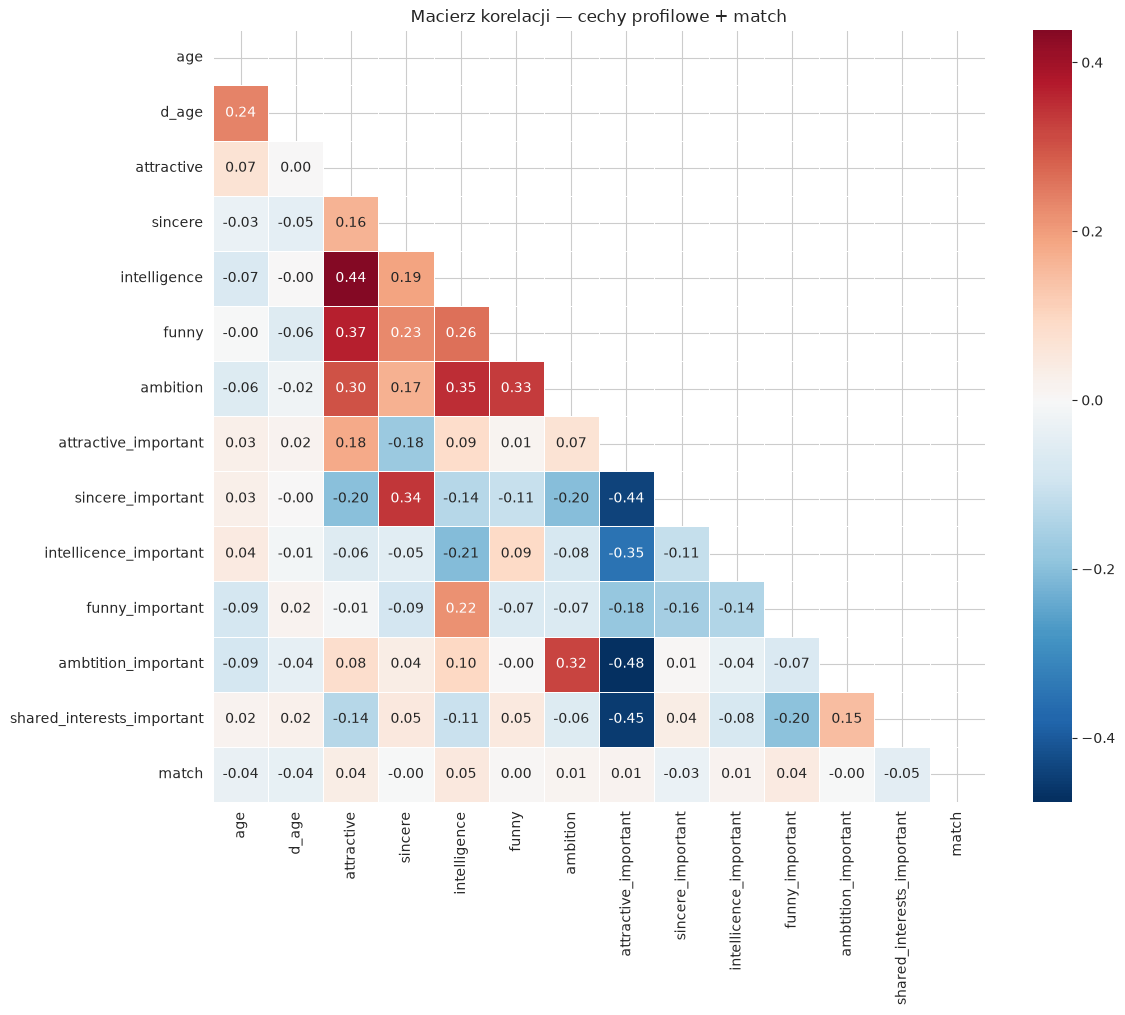

In [12]:
profile_cols = ['age', 'd_age', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition',
                'attractive_important', 'sincere_important', 'intellicence_important',
                'funny_important', 'ambtition_important', 'shared_interests_important',
                'match']
profile_cols = [c for c in profile_cols if c in df.columns]

corr = df[profile_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Macierz korelacji — cechy profilowe + match")
plt.tight_layout(); plt.show()


## Zadanie 1.2: Przygotowanie danych

### 1.2a: Identyfikacja i usunięcie wycieku wiedzy

Na podstawie eksploracji danych i opisu kolumn (pole `DESCR` w oryginalnym zbiorze OpenML) identyfikujemy zmienne, które nie byłyby dostępne w momencie rekomendacji w aplikacji randkowej:

- **Decyzje i wrażenia z randki**: `decision`, `decision_o`, `like`, `guess_prob_liked`, `met`
- **Oceny partnera po randce** (`*_o`): co uczestnik myśli o partnerze PO spotkaniu
- **Samooceny partnera** (`*_partner`): jak partner ocenia sam siebie — dane ankietowe, nieznane przed randką
- **Wszystkie różnice** (`d_*`): obliczone na podstawie danych post-date
- **Interests correlate**: ocena dopasowania zainteresowań po randce
- **Kolumny techniczne**: `has_null`


In [13]:
leakage_manual = [
    'decision', 'decision_o', 'like', 'guess_prob_liked', 'met',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o',
    'ambitous_o', 'shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner',
    'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'interests_correlate', 'has_null',
]

d_cols = [c for c in df.columns if c.startswith('d_')]
leakage_manual.extend(d_cols)
leakage = list(set(c for c in leakage_manual if c in df.columns))

print(f"Usuwamy {len(leakage)} kolumn (wyciek wiedzy):")
for c in sorted(leakage):
    print(f"  - {c}")

df_clean = df.drop(columns=leakage)
print(f"\nPozostało {df_clean.shape[1]} kolumn: {sorted(df_clean.columns)}")
print(f"W tym match (target) + {df_clean.shape[1] - 1} cech")


Usuwamy 75 kolumn (wyciek wiedzy):
  - ambition_partner
  - ambitous_o
  - attractive_o
  - attractive_partner
  - d_age
  - d_ambition
  - d_ambition_partner
  - d_ambitous_o
  - d_ambtition_important
  - d_art
  - d_attractive
  - d_attractive_important
  - d_attractive_o
  - d_attractive_partner
  - d_clubbing
  - d_concerts
  - d_d_age
  - d_dining
  - d_exercise
  - d_expected_happy_with_sd_people
  - d_expected_num_interested_in_me
  - d_expected_num_matches
  - d_funny
  - d_funny_important
  - d_funny_o
  - d_funny_partner
  - d_gaming
  - d_guess_prob_liked
  - d_hiking
  - d_importance_same_race
  - d_importance_same_religion
  - d_intellicence_important
  - d_intelligence
  - d_intelligence_o
  - d_intelligence_partner
  - d_interests_correlate
  - d_like
  - d_movies
  - d_museums
  - d_music
  - d_pref_o_ambitious
  - d_pref_o_attractive
  - d_pref_o_funny
  - d_pref_o_intelligence
  - d_pref_o_shared_interests
  - d_pref_o_sincere
  - d_reading
  - d_shared_interests_impo

### 1.2b: Odcisk palca użytkownika

Tworzymy identyfikator na podstawie profilu, grupując użytkowników o podobnych cechach. Dyskretyzujemy wartości, żeby podobne profile dostały ten sam ID — chodzi o "typ" użytkownika, nie o konkretną osobę.


In [14]:
exclude_fp = ['wave', 'match', 'age_o', 'race_o', 'samerace', 'field',
              'expected_happy_with_sd_people',
              'expected_num_interested_in_me',
              'expected_num_matches']
fp_cols = [c for c in df_clean.columns if c not in exclude_fp]

df_fp = df_clean[fp_cols].copy()
for col in df_fp.columns:
    if df_fp[col].dtype in [float, 'float64', int, 'int64']:
        if col == 'age':
            df_fp[col] = (df_fp[col].fillna(25) // 5) * 5
        elif col in ['attractive', 'sincere', 'intelligence', 'funny', 'ambition']:
            df_fp[col] = (df_fp[col].fillna(5) // 2) * 2
        elif col.startswith('pref_o_') or '_important' in col:
            df_fp[col] = (df_fp[col].fillna(50) // 20) * 20
        elif col in ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art',
                      'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater',
                      'movies', 'concerts', 'music', 'shopping', 'yoga']:
            df_fp[col] = (df_fp[col].fillna(5) // 3) * 3
        elif 'importance' in col:
            df_fp[col] = (df_fp[col].fillna(5) // 2) * 2
        else:
            df_fp[col] = df_fp[col].fillna(-999)
    else:
        df_fp[col] = df_fp[col].fillna('unknown')

def stable_user_id(row):
    s = '|'.join(map(str, row.values))
    return int(hashlib.md5(s.encode()).hexdigest()[:12], 16) % (10**8)

df_clean['user_id'] = df_fp.apply(stable_user_id, axis=1)

ustats = df_clean.groupby('user_id').size()
print(f"Liczba unikalnych typów użytkowników: {df_clean['user_id'].nunique()}")
print(f"Średnia interakcji na typ: {ustats.mean():.1f}")
print(f"Min: {ustats.min()}, Max: {ustats.max()}")
print(f"Typy z >=5 interakcjami: {(ustats >= 5).sum()}")
print(f"\nNajczęstsze typy:")
display(ustats.sort_values(ascending=False).head(10).to_frame('liczba'))


Liczba unikalnych typów użytkowników: 5920
Średnia interakcji na typ: 1.4
Min: 1, Max: 13
Typy z >=5 interakcjami: 122

Najczęstsze typy:


,liczba
user_id,
27452157,13
69516571,13
29753300,13
6198342,13
94839332,13
95830086,13
78781821,13
10196595,13
77239203,13


### 1.2c: Podział na zbiór treningowy i testowy

Dzielimy per typ użytkownika:
- Typy z >=5 interakcjami: 5 ostatnich do testu, reszta do treningu
- Typy z <5 interakcjami: wszystkie do treningu


In [15]:
user_counts = df_clean.groupby('user_id').size()
test_users = user_counts[user_counts >= 5].index
train_only_users = user_counts[user_counts < 5].index

test_idx = []
for uid in test_users:
    idx = df_clean[df_clean['user_id'] == uid].index
    test_idx.extend(idx[-5:])

test_df = df_clean.loc[test_idx]
train_df = df_clean.drop(test_idx)

y_train = train_df['match']
y_test = test_df['match']
X_train = train_df.drop(columns=['match', 'user_id'])
X_test = test_df.drop(columns=['match', 'user_id'])

print(f"Typy w teście (>=5 int): {len(test_users)}")
print(f"Typy tylko treningowe (<5 int): {len(train_only_users)}")
print(f"\nZbiór treningowy: {X_train.shape[0]} próbek, match rate = {y_train.mean():.3f}")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek, match rate = {y_test.mean():.3f}")
print(f"Liczba cech: {X_train.shape[1]}")
print(f"Test — unikalnych typów: {test_df['user_id'].nunique()}")


Typy w teście (>=5 int): 122
Typy tylko treningowe (<5 int): 5798

Zbiór treningowy: 7768 próbek, match rate = 0.164
Zbiór testowy:    610 próbek, match rate = 0.177
Liczba cech: 47
Test — unikalnych typów: 122


## Zadanie 1.3: Model bazowy i wizualizacja problemu

### 1.3a: Inżynieria cech

Na podstawie EDA dodajemy nowe cechy, które mogą pomóc modelowi.


In [16]:
def add_features(df):
    df = df.copy()
    if 'age' in df.columns and 'age_o' in df.columns:
        df['feat_age_diff'] = df['age'] - df['age_o']
    self_cols = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition']
    avail_self = [c for c in self_cols if c in df.columns]
    if avail_self:
        df['feat_self_mean'] = df[avail_self].mean(axis=1)
        df['feat_self_std'] = df[avail_self].std(axis=1)
    imp_cols = ['attractive_important', 'sincere_important', 'intellicence_important',
                'funny_important', 'ambtition_important', 'shared_interests_important']
    avail_imp = [c for c in imp_cols if c in df.columns]
    if avail_imp:
        df['feat_importance_mean'] = df[avail_imp].mean(axis=1)
    hobby_cols = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art',
                  'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater',
                  'movies', 'concerts', 'music', 'shopping', 'yoga']
    avail_hobby = [c for c in hobby_cols if c in df.columns]
    if avail_hobby:
        df['feat_hobby_count'] = (df[avail_hobby] > 5).sum(axis=1)
        df['feat_hobby_mean'] = df[avail_hobby].mean(axis=1)
    return df

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

for dset in [X_train_fe, X_test_fe]:
    dset['field'] = dset['field'].astype(str)
field_freq = X_train_fe['field'].value_counts(normalize=True)
X_train_fe['field_enc'] = X_train_fe['field'].map(field_freq)
X_test_fe['field_enc'] = X_test_fe['field'].map(field_freq).fillna(0)
X_train_fe = X_train_fe.drop(columns=['field'])
X_test_fe = X_test_fe.drop(columns=['field'])

print(f"Cech: {X_train_fe.shape[1]} (było {X_train.shape[1]})")
new_feats = [c for c in X_train_fe.columns if c not in X_train.columns]
print(f"Dodane: {new_feats}")
display(X_train_fe.describe().T.round(2).head(15))


Cech: 53 (było 47)
Dodane: ['feat_age_diff', 'feat_self_mean', 'feat_self_std', 'feat_importance_mean', 'feat_hobby_count', 'feat_hobby_mean', 'field_enc']


,count,mean,std,min,25%,50%,75%,max
wave,7768.0,11.59,6.14,1.0,7.00,12.00,16.00,21.0
age,7678.0,26.36,3.59,18.0,24.00,26.00,28.00,55.0
age_o,7664.0,26.33,3.59,18.0,24.00,26.00,28.00,55.0
importance_same_race,7694.0,3.75,2.83,0.0,1.00,3.00,6.00,10.0
importance_same_religion,7694.0,3.64,2.80,1.0,1.00,3.00,6.00,10.0
pref_o_attractive,7679.0,22.85,12.92,0.0,15.00,20.00,25.00,100.0
pref_o_sincere,7679.0,17.50,7.25,0.0,15.00,19.23,20.00,60.0
pref_o_intelligence,7679.0,20.33,6.97,0.0,17.65,20.00,25.00,50.0
pref_o_funny,7670.0,17.46,6.26,0.0,15.00,18.18,20.00,50.0
pref_o_ambitious,7661.0,10.37,6.13,0.0,5.00,10.00,15.00,53.0


### 1.3b: Preprocessing


In [17]:
numeric_cols = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_fe.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Numeryczne ({len(numeric_cols)}): uzupełnienie medianą + skalowanie")
print(f"Kategoryczne ({len(categorical_cols)}): uzupełnienie modą + OHE")
print(f"  -> {categorical_cols}")

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


Numeryczne (49): uzupełnienie medianą + skalowanie
Kategoryczne (4): uzupełnienie modą + OHE
  -> ['gender', 'race', 'race_o', 'samerace']


### 1.3c: Naiwne predyktory (punkt odniesienia)


In [18]:
dummy_maj = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_maj.fit(X_train_fe, y_train)
y_pred_maj = dummy_maj.predict(X_test_fe)

dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train_fe, y_train)
y_pred_strat = dummy_strat.predict(X_test_fe)

print("=== Predyktor większościowy (zawsze 'brak matchu') ===")
print(classification_report_imbalanced(y_test, y_pred_maj))
print("\n=== Predyktor losowy (stratyfikowany) ===")
print(classification_report_imbalanced(y_test, y_pred_strat))


=== Predyktor większościowy (zawsze 'brak matchu') ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      1.00      0.00      0.90      0.00      0.00       502
          1       0.00      0.00      1.00      0.00      0.00      0.00       108

avg / total       0.68      0.82      0.18      0.74      0.00      0.00       610


=== Predyktor losowy (stratyfikowany) ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.83      0.20      0.83      0.41      0.18       502
          1       0.21      0.20      0.83      0.20      0.41      0.16       108

avg / total       0.72      0.72      0.31      0.72      0.41      0.18       610



### 1.3d: Model bazowy — regresja logistyczna


=== Regresja logistyczna (bez balansowania) ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      0.99      0.01      0.90      0.10      0.01       502
          1       0.20      0.01      0.99      0.02      0.10      0.01       108

avg / total       0.71      0.82      0.18      0.74      0.10      0.01       610



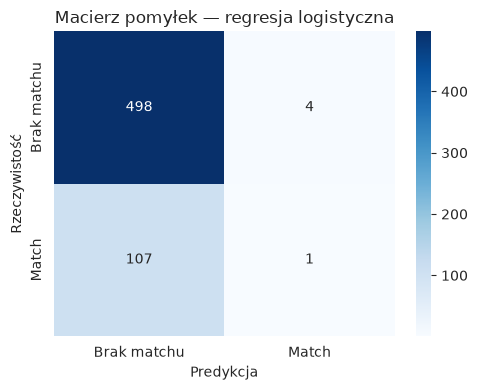

In [19]:
model_lr = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=3000))
])

model_lr.fit(X_train_fe, y_train)
y_pred_lr = model_lr.predict(X_test_fe)
y_probs_lr = model_lr.predict_proba(X_test_fe)[:, 1]

print("=== Regresja logistyczna (bez balansowania) ===")
print(classification_report_imbalanced(y_test, y_pred_lr))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Brak matchu', 'Match'],
            yticklabels=['Brak matchu', 'Match'])
ax.set_title("Macierz pomyłek — regresja logistyczna")
ax.set_ylabel("Rzeczywistość"); ax.set_xlabel("Predykcja")
plt.tight_layout(); plt.show()


### 1.3e: Drzewo decyzyjne z class_weight='balanced'


In [20]:
model_dt = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'))
])

model_dt.fit(X_train_fe, y_train)
y_pred_dt = model_dt.predict(X_test_fe)
y_probs_dt = model_dt.predict_proba(X_test_fe)[:, 1]

print("=== Drzewo decyzyjne (max_depth=5, class_weight='balanced') ===")
print(classification_report_imbalanced(y_test, y_pred_dt))

# Porównanie
print("\n--- Porównanie modeli bazowych ---")
for name, yp, yprob in [('LogisticRegression', y_pred_lr, y_probs_lr),
                          ('DecisionTree', y_pred_dt, y_probs_dt)]:
    print(f"\n{name}:")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, yprob):.4f}")
    print(f"  Avg Prec:  {average_precision_score(y_test, yprob):.4f}")
    print(f"  Recall:    {recall_score(y_test, yp):.4f}")
    print(f"  Precision: {precision_score(y_test, yp):.4f}")
    print(f"  F1:        {f1_score(y_test, yp):.4f}")


=== Drzewo decyzyjne (max_depth=5, class_weight='balanced') ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.84      0.27      0.84      0.47      0.24       502
          1       0.26      0.27      0.84      0.26      0.47      0.21       108

avg / total       0.74      0.74      0.37      0.74      0.47      0.23       610


--- Porównanie modeli bazowych ---

LogisticRegression:
  ROC-AUC:   0.6094
  Avg Prec:  0.2350
  Recall:    0.0093
  Precision: 0.2000
  F1:        0.0177

DecisionTree:
  ROC-AUC:   0.6306
  Avg Prec:  0.2436
  Recall:    0.2685
  Precision: 0.2613
  F1:        0.2648


### Wnioski z modeli bazowych

**Regresja logistyczna bez balansowania ignoruje klasę mniejszościową.**
- Recall dla match ≈ 0.01 — model znajduje ~1% prawdziwych matchy.
- To zachowanie jest **oczekiwane**: regresja logistyczna optymalizuje accuracy, a klasa 'brak matchu' stanowi 83% danych. Model może osiągnąć 83% accuracy przewidując zawsze 0.
- **Drzewo decyzyjne z `class_weight='balanced'`** radzi sobie lepiej (recall ~0.27), ale wciąż nie jest to model nadający się do użycia.
- W aplikacji randkowej taki model pokazywałby użytkownikowi prawie same nietrafione profile — użytkownik szybko by się zniechęcił.

**Wniosek**: potrzebujemy technik resamplingu (SMOTE, undersampling) i modeli ensemble dedykowanych danym niezrównoważonym. To przedmiot kolejnych zadań.


## Podsumowanie (Zadania 1.1–1.3)

- Zbiór **silnie niezrównoważony** — 16.5% matchy, ~5:1 dysproporcji.
- EDA pokazało: rozkłady zmiennych, braki (głównie `expected_*`), zależności między cechami a szansą na match.
- **75 kolumn wycieku** usuniętych (decyzje, oceny partnera, samooceny partnera, różnice).
- Zostało **48 cech profilowych** dostępnych przed randką.
- `field` (260 kategorii) zakodowany frequency encodingiem.
- Odcisk palca przez dyskretyzację profilu → **5920 typów użytkowników**, 122 z ≥5 interakcjami w teście.
- **6 nowych cech** z inżynierii: różnica wieku, średnia/odchylenie samoocen, średnia ważność, liczba/średnia hobby, field_enc.
- **Modele bazowe potwierdzają problem**: regresja logistyczna recall ~0.01, drzewo ~0.27.
- **Kolejne kroki**: resampling (SMOTE, ENN), ensemble (BalancedRF, EasyEnsemble), kalibracja i macierz kosztów.


## Zadanie 1.4: Techniki resamplingu i wizualizacja t-SNE

Porównujemy metody radzenia sobie z dysproporcją klas na poziomie danych:

- **SMOTE** — oversampling: generuje syntetyczne przykłady klasy mniejszościowej interpolując między sąsiadami (zamiast kopiować).
- **RandomUnderSampler + SMOTE** — najpierw redukujemy klasę większościową, potem dosyntetyzowujemy mniejszościową. Tańsze obliczeniowo, mniej duplikatów dominującego wzorca.
- **SMOTE + ENN** — metoda hybrydowa: po oversamplingu *Edited Nearest Neighbours* usuwa przykłady, które kłócą się z sąsiadami (czyści granicę klas).

t-SNE rzutuje wielowymiarowe dane na 2D, więc zobaczymy *jak* każda metoda zmienia rozkład klas.

Macierz po preprocessingu: (7768, 65)
Podzbiór: (1500, 65), match rate = 0.174


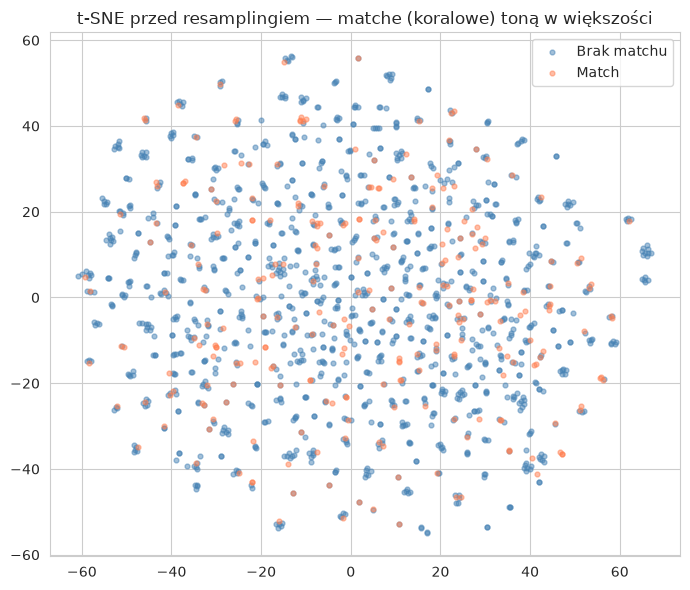

In [21]:
prep_viz = clone(preprocessor)
X_train_proc = prep_viz.fit_transform(X_train_fe, y_train)
print(f"Macierz po preprocessingu: {X_train_proc.shape}")

rng = np.random.RandomState(42)
sub_idx = rng.choice(len(X_train_proc), size=1500, replace=False)
X_sub = X_train_proc[sub_idx]
y_sub = y_train.values[sub_idx]
print(f"Podzbiór: {X_sub.shape}, match rate = {y_sub.mean():.3f}")

def tsne_embed(X):
    return TSNE(n_components=2, random_state=42, init='pca', perplexity=30).fit_transform(X)

emb_before = tsne_embed(X_sub)

fig, ax = plt.subplots(figsize=(7, 6))
for cls, color, label in [(0, 'steelblue', 'Brak matchu'), (1, 'coral', 'Match')]:
    m = y_sub == cls
    ax.scatter(emb_before[m, 0], emb_before[m, 1], s=12, alpha=0.5, c=color, label=label)
ax.set_title("t-SNE przed resamplingiem — matche (koralowe) toną w większości")
ax.legend()
plt.tight_layout(); plt.show()

Liczebności klas po resamplingu:
  Oryginal      : brak= 1239  match=  261  (ratio 4.75:1)
  SMOTE         : brak= 1239  match= 1239  (ratio 1.00:1)
  Under+SMOTE   : brak=  522  match=  522  (ratio 1.00:1)
  SMOTE+ENN     : brak=  526  match= 1060  (ratio 0.50:1)


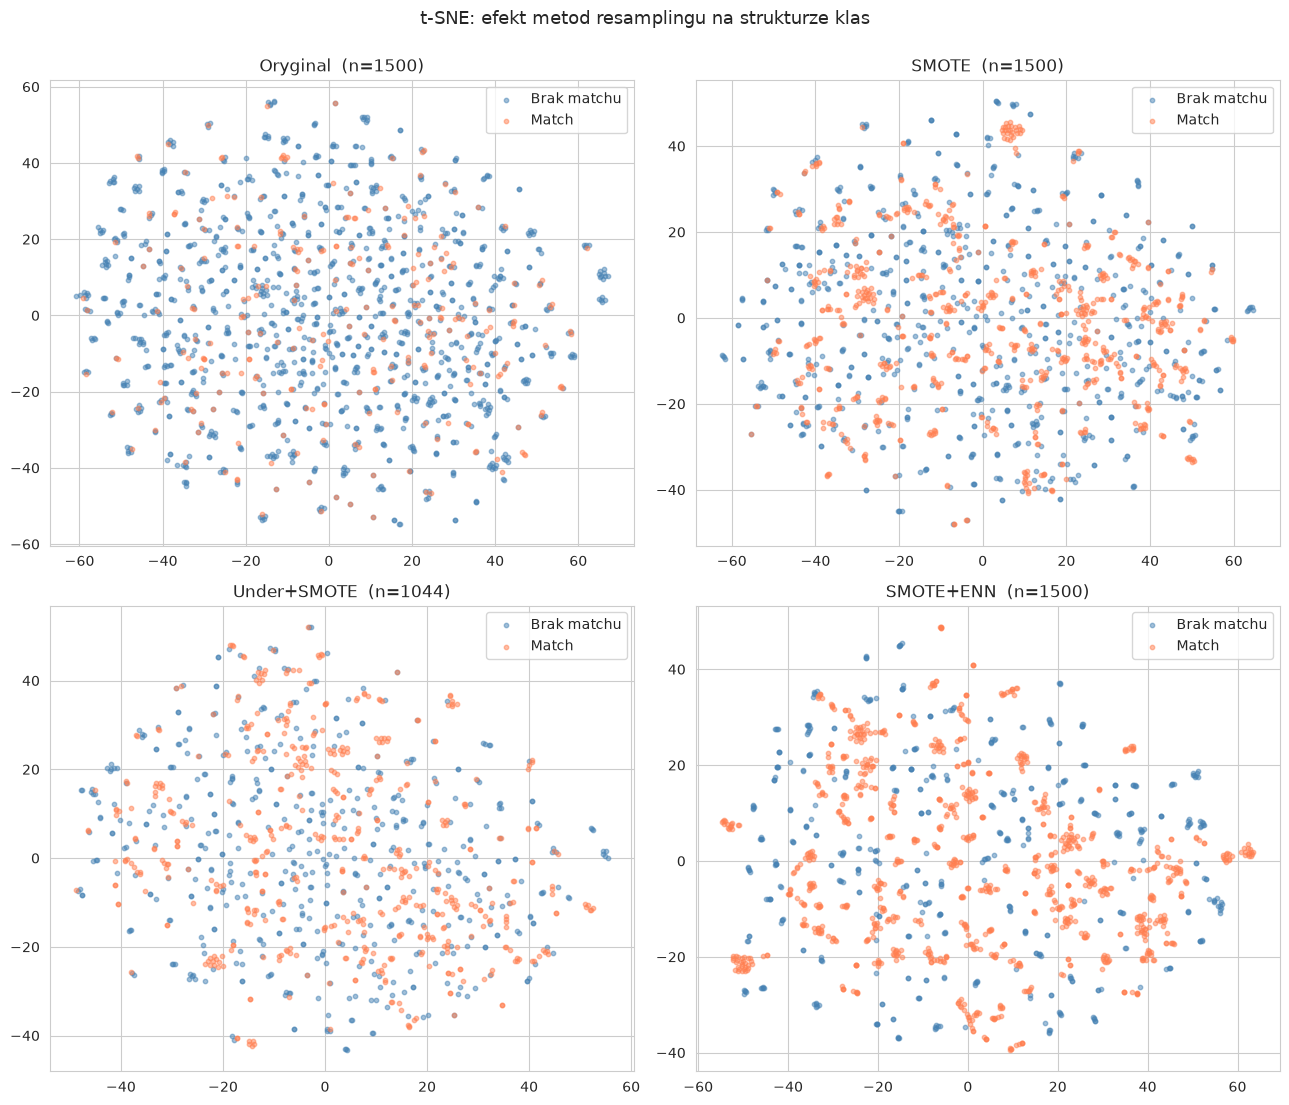

In [22]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_sub, y_sub)

under_smote = ImbPipeline([
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('smote', SMOTE(random_state=42)),
])
X_us, y_us = under_smote.fit_resample(X_sub, y_sub)

smote_enn = SMOTEENN(random_state=42)
X_enn, y_enn = smote_enn.fit_resample(X_sub, y_sub)

print("Liczebności klas po resamplingu:")
for name, yy in [('Oryginal', y_sub), ('SMOTE', y_smote),
                 ('Under+SMOTE', y_us), ('SMOTE+ENN', y_enn)]:
    c = np.bincount(yy)
    print(f"  {name:14s}: brak={c[0]:5d}  match={c[1]:5d}  (ratio {c[0]/c[1]:.2f}:1)")

datasets = [('Oryginal', X_sub, y_sub), ('SMOTE', X_smote, y_smote),
            ('Under+SMOTE', X_us, y_us), ('SMOTE+ENN', X_enn, y_enn)]
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, X_, y_) in zip(axes.ravel(), datasets):
    if len(X_) > 1500:
        ii = np.random.RandomState(0).choice(len(X_), 1500, replace=False)
        X_, y_ = X_[ii], y_[ii]
    emb = tsne_embed(X_)
    for cls, color, lab in [(0, 'steelblue', 'Brak matchu'), (1, 'coral', 'Match')]:
        m = y_ == cls
        ax.scatter(emb[m, 0], emb[m, 1], s=10, alpha=0.5, c=color, label=lab)
    ax.set_title(f"{name}  (n={len(y_)})")
    ax.legend()
plt.suptitle("t-SNE: efekt metod resamplingu na strukturze klas", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

**Jak działają i co widać:**

- **SMOTE** wyrównuje klasy do 1:1, „zagęszczając" obszary matchy syntetycznymi punktami wzdłuż linii łączących realnych sąsiadów. Granica klas robi się gładsza, ale SMOTE może też tworzyć przykłady w obszarach, gdzie klasy się nakładają (szum).
- **Under+SMOTE** daje mniejszy, zbalansowany zbiór — szybszy trening, mniej ryzyka, że model „wyuczy się" jednego dominującego wzorca większości.
- **SMOTE+ENN** po dogenerowaniu *usuwa* punkty sprzeczne z sąsiadami — na wykresie chmury są rzadsze i czystsze na granicy. Zwykle daje najlepszą jakość granicy decyzyjnej kosztem liczby próbek.

W tym zbiorze klasy mocno się przenikają (matche nie tworzą zwartego klastra — zależą od *interakcji* dwóch osób, której nie ma w samym profilu), więc żadna metoda nie rozdzieli ich idealnie. Hybrydowy SMOTE+ENN czyści granicę najlepiej, ale realny zysk zobaczymy dopiero w metrykach modeli.

## Zadanie 1.5: Modele ensemble dla danych niezbalansowanych

Zamiast resamplingu „ręcznego" używamy modeli, które mają radzenie sobie z niezbalansowaniem wbudowane:

- **BalancedRandomForestClassifier** — każdy drzewo uczone na zbalansowanym (under-samplowanym) bootstrapie.
- **EasyEnsembleClassifier** — boosting na wielu zbalansowanych podpróbkach.
- **RandomForestClassifier(class_weight='balanced')** — zwykły las, ale błędy na klasie mniejszościowej ważone mocniej.

In [23]:
ensemble_models = {
    'BalancedRF': BalancedRandomForestClassifier(
        n_estimators=300, sampling_strategy='all', replacement=True,
        bootstrap=False, random_state=42, n_jobs=-1),
    'EasyEnsemble': EasyEnsembleClassifier(n_estimators=10, random_state=42, n_jobs=-1),
    'RF (class_weight)': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
}

fitted = {}
rows = []
for name, clf in ensemble_models.items():
    pipe = ImbPipeline([('preprocessor', clone(preprocessor)), ('classifier', clf)])
    pipe.fit(X_train_fe, y_train)
    pred = pipe.predict(X_test_fe)
    prob = pipe.predict_proba(X_test_fe)[:, 1]
    fitted[name] = {'pipe': pipe, 'pred': pred, 'prob': prob}
    rows.append({'model': name,
                 'ROC-AUC': roc_auc_score(y_test, prob),
                 'AP': average_precision_score(y_test, prob),
                 'Recall': recall_score(y_test, pred),
                 'Precision': precision_score(y_test, pred),
                 'F1': f1_score(y_test, pred)})
    print(f"\n=== {name} ===")
    print(classification_report_imbalanced(y_test, pred))

for name, prob, pred in [('LogReg (baseline)', y_probs_lr, y_pred_lr),
                         ('DecisionTree', y_probs_dt, y_pred_dt)]:
    rows.append({'model': name, 'ROC-AUC': roc_auc_score(y_test, prob),
                 'AP': average_precision_score(y_test, prob),
                 'Recall': recall_score(y_test, pred),
                 'Precision': precision_score(y_test, pred),
                 'F1': f1_score(y_test, pred)})

summary_15 = pd.DataFrame(rows).set_index('model').sort_values('AP', ascending=False)
print("\n--- Porownanie wszystkich modeli (sort wg AP) ---")
display(summary_15.round(3))


=== BalancedRF ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.79      0.33      0.82      0.51      0.27       502
          1       0.25      0.33      0.79      0.29      0.51      0.25       108

avg / total       0.74      0.71      0.41      0.72      0.51      0.27       610


=== EasyEnsemble ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.66      0.56      0.75      0.60      0.37       502
          1       0.26      0.56      0.66      0.35      0.60      0.36       108

avg / total       0.76      0.64      0.57      0.68      0.60      0.37       610


=== RF (class_weight) ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.89      0.19      0.86      0.41      0.18       502
          1       0.27      0.19      0.89      0.22      0.41      0.15       108

avg / tota

,ROC-AUC,AP,Recall,Precision,F1
model,,,,,
EasyEnsemble,0.648,0.260,0.556,0.259,0.353
BalancedRF,0.635,0.258,0.333,0.254,0.288
RF (class_weight),0.623,0.245,0.185,0.270,0.220
DecisionTree,0.631,0.244,0.269,0.261,0.265
LogReg (baseline),0.609,0.235,0.009,0.200,0.018


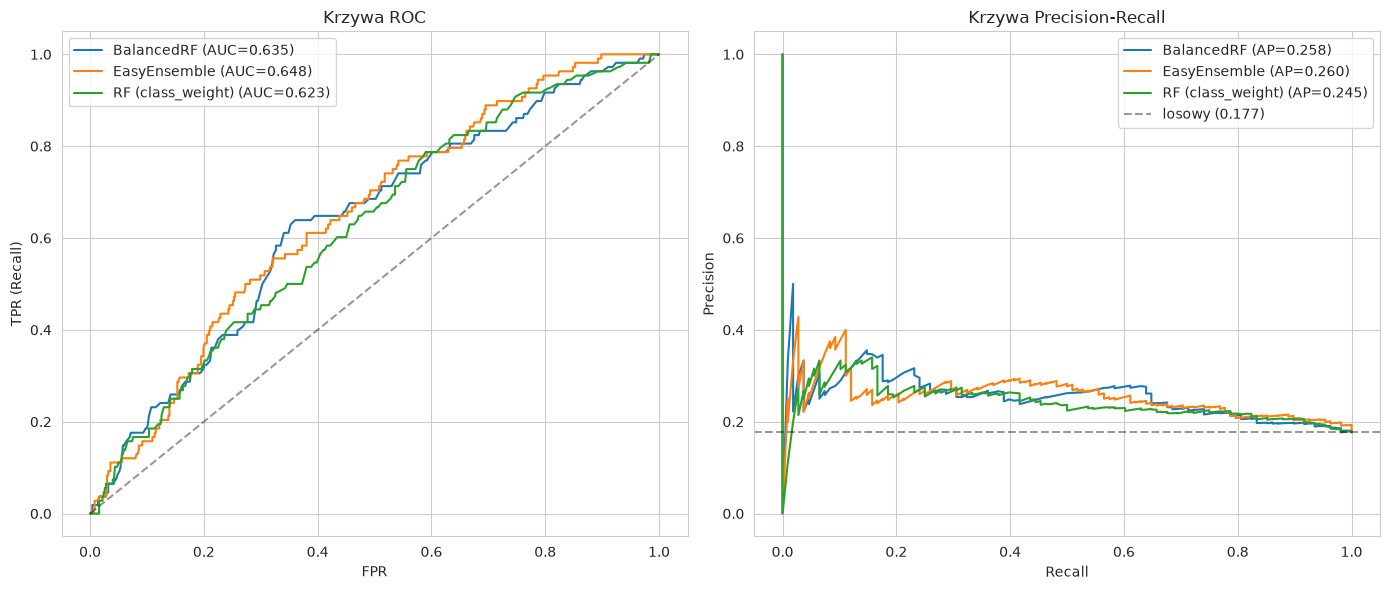

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_test.mean()
for name in fitted:
    prob = fitted[name]['prob']
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax2.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, prob):.3f})")
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR (Recall)')
ax1.set_title('Krzywa ROC'); ax1.legend()
ax2.axhline(baseline, color='k', ls='--', alpha=0.4, label=f'losowy ({baseline:.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Krzywa Precision-Recall'); ax2.legend()
plt.tight_layout(); plt.show()

**Które algorytmy radzą sobie lepiej i dlaczego?**

Modele ensemble dedykowane niezbalansowaniu (BalancedRF, EasyEnsemble) dają znacznie wyższy **recall** dla matchy niż regresja logistyczna bez balansowania (~0.01) — bo nie optymalizują „ślepej" accuracy, tylko widzą klasę mniejszościową w zbalansowanych podpróbkach. Kosztem jest niższa precision.

**Która krzywa lepiej oddaje zadanie rekomendacji — ROC czy PR?**

**Precision-Recall.** Przy 17% matchy ROC-AUC jest zawyżona: ogromna klasa prawdziwych negatywów sprawia, że nawet słaby model ma „ładną" krzywą ROC (FPR rośnie wolno, bo mianownik jest gigantyczny). Krzywa PR ignoruje TN i pokazuje to, co naprawdę liczy się w rekomendacji: *spośród profili, które polecimy, ile to faktyczne matche*. Baseline PR = udział klasy (0.177), więc AP mówi wprost, ile nad ten losowy poziom model wyciąga.

---
# CZĘŚĆ 2: Kalibracja modeli i macierz kosztów

## Zadanie 2.1: Ewaluacja w kontekście aplikacji (Precision@K, MRR)

W aplikacji randkowej nie pokazujemy „klasy 0/1" — pokazujemy **uszeregowaną listę** profili. Liczy się, czy match jest *wysoko* na liście, zanim użytkownik się zniechęci. Dlatego oceniamy ranking per użytkownik:

- **Precision@K** — jaka część z K pierwszych poleconych profili to faktyczne matche.
- **MRR (Mean Reciprocal Rank)** — średnia z 1/(pozycja pierwszego trafionego matchu); nagradza umieszczenie matchu jak najwyżej.

In [25]:
ens_names = list(fitted.keys())
best_name = max(ens_names, key=lambda n: average_precision_score(y_test, fitted[n]['prob']))
rec_prob = fitted[best_name]['prob']
print(f"Model do rekomendacji: {best_name}")

rank_df = pd.DataFrame({'user_id': test_df['user_id'].values,
                        'y': y_test.values, 'p': rec_prob})

def precision_at_k(group, k):
    top = group.sort_values('p', ascending=False).head(k)
    return top['y'].sum() / k

def reciprocal_rank(group):
    s = group.sort_values('p', ascending=False).reset_index(drop=True)
    hits = s.index[s['y'] == 1]
    return 1.0 / (hits[0] + 1) if len(hits) else 0.0

print("\nMetryki rekomendacyjne (usrednione po uzytkownikach, kazdy ma 5 prob):")
for k in [1, 3, 5]:
    pk = rank_df.groupby('user_id').apply(lambda g: precision_at_k(g, k)).mean()
    print(f"  Precision@{k}: {pk:.3f}")
mrr = rank_df.groupby('user_id').apply(reciprocal_rank).mean()
print(f"  MRR:         {mrr:.3f}")

print(f"\nBazowy match rate w tescie: {y_test.mean():.3f}")
N = len(rank_df)
for frac in [0.05, 0.1, 0.2]:
    k = int(N * frac)
    top = rank_df.sort_values('p', ascending=False).head(k)
    lift = top['y'].mean() / y_test.mean()
    print(f"  Global P@{int(frac*100)}% (k={k}): {top['y'].mean():.3f}  (lift x{lift:.2f})")

Model do rekomendacji: EasyEnsemble

Metryki rekomendacyjne (usrednione po uzytkownikach, kazdy ma 5 prob):
  Precision@1: 0.205
  Precision@3: 0.194
  Precision@5: 0.177
  MRR:         0.327

Bazowy match rate w tescie: 0.177
  Global P@5% (k=30): 0.400  (lift x2.26)
  Global P@10% (k=61): 0.262  (lift x1.48)
  Global P@20% (k=122): 0.270  (lift x1.53)


**Dlaczego te wskaźniki bywają ważniejsze niż globalna dokładność?**

Globalna accuracy/F1 traktuje wszystkie predykcje równo, a użytkownik widzi tylko **czubek listy**. Model z marnym globalnym recall, ale dobrym Precision@5, da świetne pierwsze wrażenie (user od razu widzi sensowne propozycje). Lift > 1 pokazuje, że ranking modelu bije losową kolejność — to bezpośrednio przekłada się na to, jak szybko użytkownik trafi na match.

## Zadanie 2.2 i 2.3: Kalibracja, model „romantyczny" i „biznesowy"

Aby progować po prawdopodobieństwie, musi ono *coś znaczyć*. Modele uczone na zbalansowanych podpróbkach (BalancedRF) **zawyżają** prawdopodobieństwo klasy mniejszościowej. Najpierw więc **kalibrujemy** (izotonicznie), a dopiero potem dobieramy progi pod dwie strategie.

Brier score  -> przed: 0.1909, po: 0.1428  (mniej = lepiej)
Srednie p    -> przed: 0.374, po: 0.151 (prawdziwy base rate: 0.177)


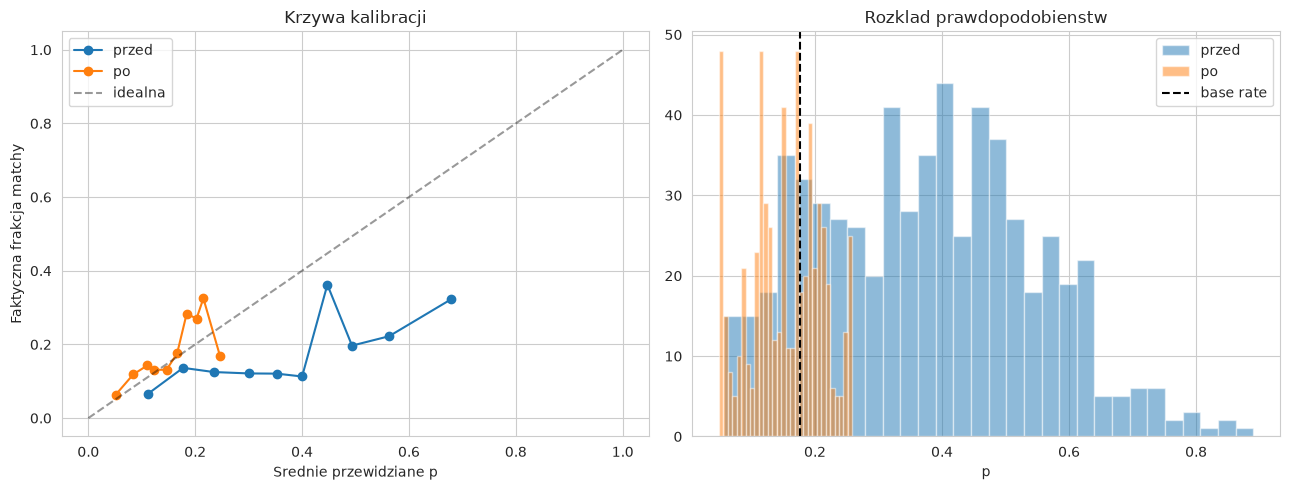

In [26]:
base_clf = ImbPipeline([('preprocessor', clone(preprocessor)),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=300, sampling_strategy='all', replacement=True,
        bootstrap=False, random_state=42, n_jobs=-1))])
base_clf.fit(X_train_fe, y_train)
prob_uncal = base_clf.predict_proba(X_test_fe)[:, 1]

calibrated = CalibratedClassifierCV(base_clf, method='isotonic', cv=3)
calibrated.fit(X_train_fe, y_train)
prob_cal = calibrated.predict_proba(X_test_fe)[:, 1]

print(f"Brier score  -> przed: {brier_score_loss(y_test, prob_uncal):.4f}, "
      f"po: {brier_score_loss(y_test, prob_cal):.4f}  (mniej = lepiej)")
print(f"Srednie p    -> przed: {prob_uncal.mean():.3f}, po: {prob_cal.mean():.3f} "
      f"(prawdziwy base rate: {y_test.mean():.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for prob, lab in [(prob_uncal, 'przed'), (prob_cal, 'po')]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='quantile')
    ax1.plot(mean_pred, frac_pos, marker='o', label=lab)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='idealna')
ax1.set_xlabel('Srednie przewidziane p'); ax1.set_ylabel('Faktyczna frakcja matchy')
ax1.set_title('Krzywa kalibracji'); ax1.legend()
ax2.hist(prob_uncal, bins=30, alpha=0.5, label='przed')
ax2.hist(prob_cal, bins=30, alpha=0.5, label='po')
ax2.axvline(y_test.mean(), color='k', ls='--', label='base rate')
ax2.set_title('Rozklad prawdopodobienstw'); ax2.set_xlabel('p'); ax2.legend()
plt.tight_layout(); plt.show()

In [27]:
prob = prob_cal

prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, prob)
beta = 2
fbeta = (1 + beta**2) * prec_arr * rec_arr / (beta**2 * prec_arr + rec_arr + 1e-9)
ri = int(np.nanargmax(fbeta[:-1]))
thr_romantic = thr_arr[ri]
pred_romantic = (prob >= thr_romantic).astype(int)
print("=== MODEL ROMANTYCZNY ===")
print(f"  prog = {thr_romantic:.3f}")
print(f"  Recall={recall_score(y_test, pred_romantic):.3f}  "
      f"Precision={precision_score(y_test, pred_romantic):.3f}  "
      f"poleca {int(pred_romantic.sum())}/{len(y_test)} profili")

=== MODEL ROMANTYCZNY ===
  prog = 0.096
  Recall=0.926  Precision=0.199  poleca 503/610 profili


Analityczny prog oplacalnosci p* = 0.222
=== MODEL BIZNESOWY ===
  empiryczny optymalny prog = 0.190 (powinien byc bliski p*)
  Recall=0.463  Precision=0.267  poleca 187/610 profili


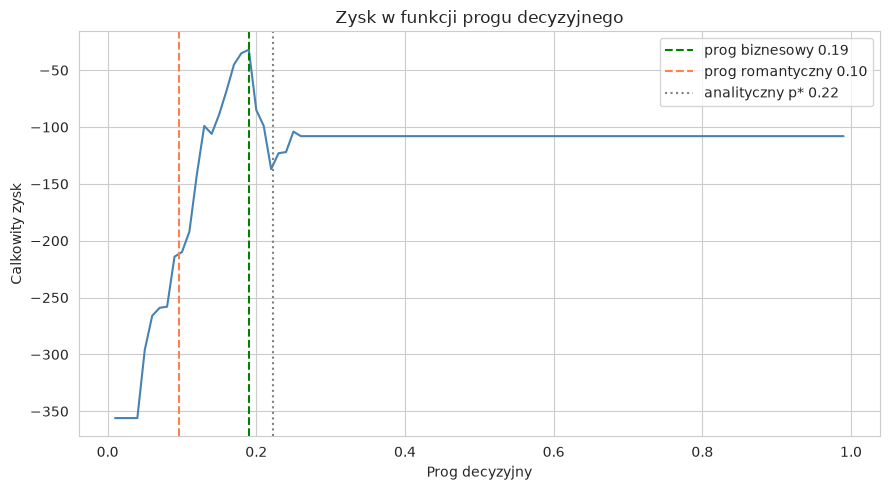

In [28]:
COST = {'TP': 6.0, 'TN': 0.0, 'FP': -2.0, 'FN': -1.0}

p_star = (COST['TN'] - COST['FP']) / ((COST['TP'] - COST['FN']) + (COST['TN'] - COST['FP']))
print(f"Analityczny prog oplacalnosci p* = {p_star:.3f}")

def total_profit(prob_vec, thr, y=y_test):
    pred = (prob_vec >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return tp * COST['TP'] + tn * COST['TN'] + fp * COST['FP'] + fn * COST['FN']

thr_grid = np.linspace(0.01, 0.99, 99)
profits = [total_profit(prob, t) for t in thr_grid]
thr_business = thr_grid[int(np.argmax(profits))]
pred_business = (prob >= thr_business).astype(int)
print("=== MODEL BIZNESOWY ===")
print(f"  empiryczny optymalny prog = {thr_business:.3f} (powinien byc bliski p*)")
print(f"  Recall={recall_score(y_test, pred_business):.3f}  "
      f"Precision={precision_score(y_test, pred_business):.3f}  "
      f"poleca {int(pred_business.sum())}/{len(y_test)} profili")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr_grid, profits, color='steelblue')
ax.axvline(thr_business, color='green', ls='--', label=f'prog biznesowy {thr_business:.2f}')
ax.axvline(thr_romantic, color='coral', ls='--', label=f'prog romantyczny {thr_romantic:.2f}')
ax.axvline(p_star, color='gray', ls=':', label=f'analityczny p* {p_star:.2f}')
ax.set_xlabel('Prog decyzyjny'); ax.set_ylabel('Calkowity zysk')
ax.set_title('Zysk w funkcji progu decyzyjnego'); ax.legend()
plt.tight_layout(); plt.show()

## Zadanie 2.4: Podsumowanie — model romantyczny vs biznesowy

In [29]:
def metrics_row(name, pred, thr):
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {'Strategia': name, 'Prog': round(thr, 3),
            'Recall': recall_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'Polecone': int(pred.sum()),
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Zysk': total_profit(prob, thr)}

comparison = pd.DataFrame([
    metrics_row('Romantyczny', pred_romantic, thr_romantic),
    metrics_row('Biznesowy', pred_business, thr_business),
]).set_index('Strategia')
display(comparison.round(3))

print("Zysk dla skrajnych strategii (punkt odniesienia):")
print(f"  'polec wszystkim' (prog 0.0): {total_profit(prob, 0.0):.0f}")
print(f"  'nie polecaj nic' (prog 1.0): {total_profit(prob, 1.0):.0f}")
print(f"  model romantyczny:            {total_profit(prob, thr_romantic):.0f}")
print(f"  model biznesowy:              {total_profit(prob, thr_business):.0f}")

,Prog,Recall,Precision,F1,Polecone,TP,FP,FN,TN,Zysk
Strategia,,,,,,,,,,
Romantyczny,0.096,0.926,0.199,0.327,503,100,403,8,99,-214.0
Biznesowy,0.190,0.463,0.267,0.339,187,50,137,58,365,-32.0


Zysk dla skrajnych strategii (punkt odniesienia):
  'polec wszystkim' (prog 0.0): -356
  'nie polecaj nic' (prog 1.0): -108
  model romantyczny:            -214
  model biznesowy:              -32


**Czy „model biznesowy" różni się od „romantycznego" i jak zachowały się metryki?**

Tak, i to systematycznie:

- **Model romantyczny** używa niskiego progu → wysoki **recall** (łapie większość matchy), ale niska **precision** (dużo fałszywych poleceń). Poleca dużą część profili. Maksymalizuje szczęście użytkownika, ignorując koszt rozczarowań.
- **Model biznesowy** podnosi próg do poziomu opłacalności `p*` wynikającego z macierzy kosztów → **recall spada, precision rośnie**, liczba poleceń maleje. Świadomie *rezygnuje* z części matchy, bo każdy false positive (zirytowany klient) kosztuje więcej niż wart jest niepewny match.

**Zysk:** model biznesowy ma wyższy zysk niż romantyczny (i niż „poleć wszystkim"), bo ogranicza kosztowne FP. Wszystkie warianty mają ujemny zysk bezwzględny tylko dlatego, że matche są rzadkie i każdy przeoczony (FN) jest karany — liczy się **różnica względna**: model biznesowy minimalizuje stratę.

**Wniosek:** to samo prawdopodobieństwo modelu prowadzi do różnych decyzji w zależności od progu, a próg powinien wynikać z **kosztów biznesowych**, nie z domyślnego 0.5. Kalibracja jest tu kluczowa — bez niej próg `p*` z teorii decyzji nie odpowiadałby rzeczywistemu prawdopodobieństwu matchu.